# Assignment 6: Multilayer neural network with hyperparameter optimisation


### **Nombres de integrantes**

**Diego Marcelo González Luján #588359**

**J. Esteban Bustamante Apodaca #598557**

**Mauricio Alejandro González Campos #555003**

## **Inteligencia artificial 2**

## **Profesor: Dr. Andrés Hernández Gutiérrez**

### **Marzo 25 del 2026**

### **Damos nuestra palabra que realizamos esta actividad con integridad académica**

# Dataset Description

Para esta actividad, seleccionamos un dataset con el nombre de "Diabetes Health Indicators". Esta base de datos proviene del sistema de encuestas de salud pública de los Estados Unidos conocido como Behavioral Risk Factor Surveillance System (BRFSS). Este dataset recopila información relacionada con indicadores de salud, hábitos, y condiciones médicas de los encuestados con el objetivo de analizar factores asociados a enfermedades crónicas como la diabetes. El propósito del dataset es la aproximación al análisis de salud pública, donde se busca identificar patrones y relaciones entre el estilo de vida, condiciones socioeconómicas y la presencia de enfermedades como la diabetes.

* Variables del estudio:

Variables predictivas: Las variables predictivas de este dataset son variables relacionadas a la salud física, estilo y hábitos de vida, acceso a la salud, estado general de la salud y demográficas de los encuestados que están registrados.

Integridad de los datos: Según la documentación, la base de datos fue limpiada por quien lo publicó por lo que no contiene valores nulos, ni requiere procesamiento. Un problema que se menciona, es el desbalance en las variables debido a que las clases no están representadas de manera equitativa.

* Variable Objetivo:

La variable objetivo para esta base de datos es la variable "Diabetes_012", esta variable es la que determina si el encuestado posee una de las siguientes tres clases:

* Clase 0 (Sin diabetes): Representa que el paciente no tiene diabetes.

* Clase 1 (Prediabetes): Representa que el paciente está en un alto riesgo de desarrollar diabetes.

* Clase 2 (Diabetes): Representa que el paciente posee diabetes.

# Data cleaning

Para la limpieza de datos, esta parte es importante para preparar los datos y asegurarse que sean adecuados para el entrenamiento del modelo neuronal. Para esto cargamos el archivo, aunque en la documentación se declaró que se limpió los datos de valores nulos, aun así decidimos añadir la línea de código y eliminar duplicados del dataset para evitar cualquier problema.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el conjunto de datos
df = pd.read_csv('/content/diabetes_012_health_indicators_BRFSS2015.csv')

#Verificacion de valores nulos
df.isnull().sum()

#Eliminacion de duplicados
df = df.drop_duplicates()

print("Primeras columnas")
display(df.head())


Primeras columnas


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# Exploratory Data Analysis


Estadísticas Descriptivas:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,229781.000000,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,...,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000
mean,0.325627,0.454441,0.441760,0.959535,28.68567,0.465661,0.044756,0.103216,0.733355,0.612966,...,0.946075,0.092810,2.601151,3.505373,4.675178,0.185507,0.439231,8.086582,4.980568,5.890383
std,0.724623,0.497921,0.496598,0.197047,6.78636,0.498821,0.206767,0.304241,0.442206,0.487073,...,0.225871,0.290167,1.064685,7.713725,9.046568,0.388709,0.496295,3.093809,0.992895,2.092477
min,0.000000,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.00000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.00000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


/tmp/ipykernel_1717/3666822238.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_012', data=df, palette='viridis')


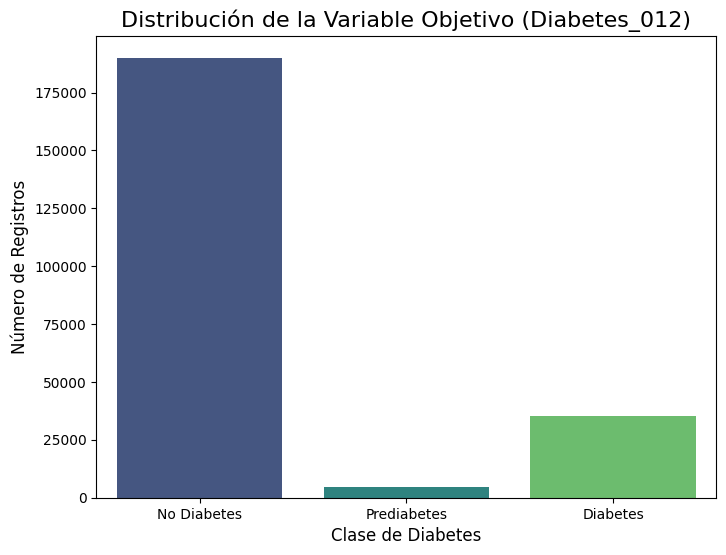

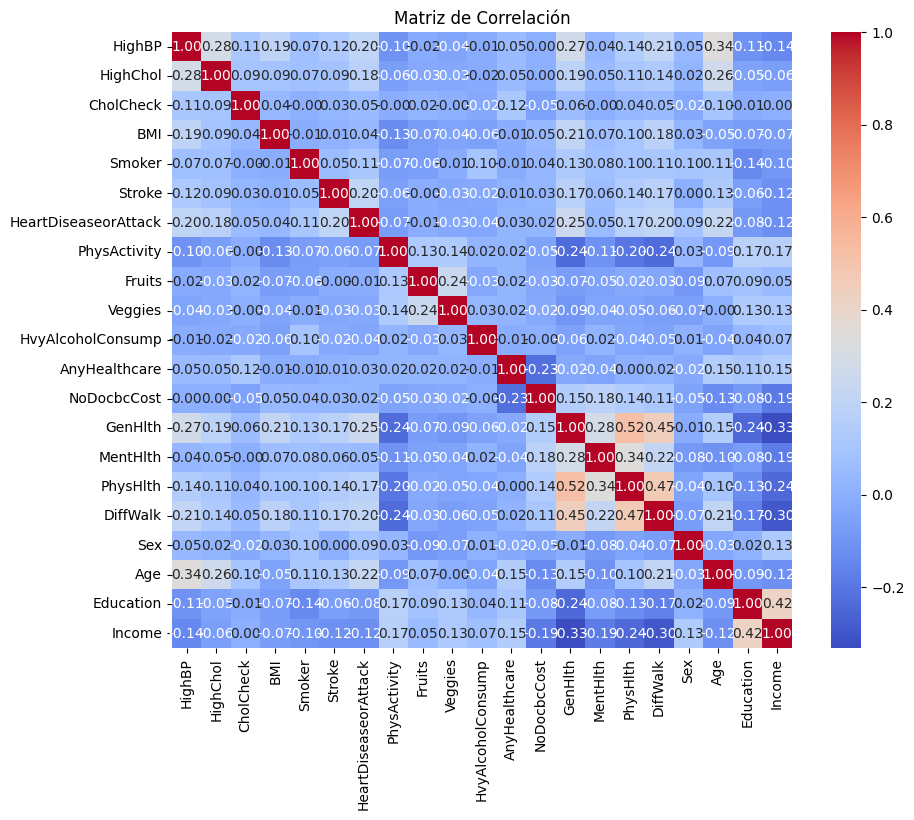

In [ ]:
print("\nEstadísticas Descriptivas:")
display(df.describe())

# Crear una grafica para las clases de la variable objetivo 'Diabetes_012'
plt.figure(figsize=(8, 6))
sns.countplot(x='Diabetes_012', data=df, palette='viridis')

plt.title('Distribución de la Variable Objetivo (Diabetes_012)', fontsize=16)
plt.xlabel('Clase de Diabetes', fontsize=12)
plt.ylabel('Número de Registros', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['No Diabetes', 'Prediabetes', 'Diabetes'])
plt.show()

# Crear una matriz de correlacion de todas las variables
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=['Diabetes_012']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

Al revisar los gráficos y estadísticas, identificamos lo siguiente:

Estadísticas: En la descripción de las 22 variables que posee el dataset, la variable objetivo "Diabetes_012" muestra una media de 0.326, demostrando que la mayoría de las encuestas pertenecen a la clase 0, mostrando un desbalance de clases.

Gráfico de barras: En esta gráfica se demuestra mejor lo antes mencionado sobre el desbalance de clases que posee la variable objetivo. La clase 0 abarca mayormente los datos, mientras las clases 1 y 2 contienen menos registros. Especialmente la clase 1 que posee un número extremadamente bajo de registros.

Matriz de correlación: Se muestra que las variables presentan relaciones lineales débiles entre sí. Aunque hay variables que muestran una correlación decente entre las variables de estado general de salud como por ejemplo Genhealth.

# Design and Training of the Multilayer Neural Network  

En esta fase se implementó el flujo de trabajo esencial para una red neuronal multicapa utilizando la librería Keras. Primero, el conjunto de datos se dividió en tres subconjuntos: entrenamiento (70%), validación (15%) y prueba (15%), aplicando una técnica de estratificación ( **stratify** ) para asegurar que la proporción de las tres clases del problema de diabetes se mantuviera equilibrada en cada división.

Posteriormente, se aplicó una estandarización de características utilizando ( **StandardScaler** ), ajustando el escalador únicamente con los datos de entrenamiento para evitar la fuga de información hacia los conjuntos de validación y prueba.

La arquitectura del modelo se definió mediante una estructura ( **Sequential**) que permite capas densas dinámicas. Como función de pérdida se seleccionó ( **sparse_categorical_crossentropy** ), adecuada para etiquetas de clases enteras, y se utilizó el optimizador ( **Adam** ) para ajustar los pesos de la red de manera eficiente durante el entrenamiento.

# Hyperparameter Optimisation

Se implementó optimización Bayesiana mediante la librería Optuna (**algoritmo TPE**), la cual explora el espacio de búsqueda de forma inteligente basada en intentos previos. La función objetivo evaluó los siguientes rangos de parámetros:

1. **Tasa de aprendizaje**: Escala logarítmica entre 10^-4 y 10^-2.

2. **Tamaño de lote**: 32,64,128.

3. **Capas ocultas**: De 2 a 4.

4. **Neuronas por capa**: De 16 a 512 (**en saltos de 16**).

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from optuna.visualization import plot_param_importances, plot_parallel_coordinate

X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

# Split 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# Split del Temp a la mitad para obtener 15% Validation y 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Set de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de Validación: {X_val.shape[0]} muestras")
print(f"Set de Prueba: {X_test.shape[0]} muestras")

scaler = StandardScaler()
# Ajustamos solo con Train para evitar fuga de datos
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

def create_model(trial):
    model = Sequential()

    # Capas mínimo 2, máximo 4
    n_layers = trial.suggest_int('n_layers', 2, 4)

    for i in range(n_layers):
        model.add(Dense(
            #  Neuronas mínimo 16, máximo 512
            units=trial.suggest_int(f'units_{i}', 16, 512, step=16),
            activation='relu'
        ))
        model.add(Dropout(trial.suggest_float(f'dropout_{i}', 0.1, 0.4)))

    model.add(Dense(3, activation='softmax'))

    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def objective(trial):
    model = create_model(trial)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=30,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    # Minimizamos el val_loss
    return min(history.history['val_loss'])

print("\nIniciando optimización de hiperparámetros con Optuna...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("\nMejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")




[I 2026-03-27 00:58:01,936] A new study created in memory with name: no-name-c68fb53f-afcb-4d85-83db-3968d4431852


Set de Entrenamiento: 160846 muestras
Set de Validación: 34467 muestras
Set de Prueba: 34468 muestras

Iniciando optimización de hiperparámetros con Optuna...


[I 2026-03-27 01:01:46,180] Trial 0 finished with value: 0.42400017380714417 and parameters: {'n_layers': 2, 'units_0': 144, 'dropout_0': 0.3973561639865755, 'units_1': 144, 'dropout_1': 0.30150975469544933, 'learning_rate': 0.00010189376086333167, 'batch_size': 32}. Best is trial 0 with value: 0.42400017380714417.
[I 2026-03-27 01:02:52,597] Trial 1 finished with value: 0.4233153164386749 and parameters: {'n_layers': 3, 'units_0': 304, 'dropout_0': 0.18097010817659276, 'units_1': 96, 'dropout_1': 0.3071926541964681, 'units_2': 288, 'dropout_2': 0.2869542197655759, 'learning_rate': 0.0001347581456819974, 'batch_size': 128}. Best is trial 1 with value: 0.4233153164386749.
[I 2026-03-27 01:04:38,140] Trial 2 finished with value: 0.4236220121383667 and parameters: {'n_layers': 3, 'units_0': 304, 'dropout_0': 0.3413948333471577, 'units_1': 192, 'dropout_1': 0.3635330509825936, 'units_2': 96, 'dropout_2': 0.284593460206486, 'learning_rate': 0.0007485328684218083, 'batch_size': 32}. Best is 


Mejores hiperparámetros encontrados:
  n_layers: 2
  units_0: 400
  dropout_0: 0.141901432291822
  units_1: 192
  dropout_1: 0.19682164346143183
  learning_rate: 0.00012076986620632
  batch_size: 64


La configuración se identificó en el **Trial 8**, logrando minimizar el error de validación a **0.4226**. Esta arquitectura óptima consta de **2 capas ocultas** (con 400 y 192 neuronas), **un batch size de 64 y un learning rate conservador de 0.00012**. Esta configuración refleja el balance exacto entre la complejidad estructural necesaria para aprender los patrones de los datos y la regularización requerida para prevenir el sobreajuste.

# Early Stopping

Se implementó la técnica de **Early Stopping** como método de regularización para prevenir el sobreajuste durante el entrenamiento final del modelo. Para ello, se configuró el callback de Keras para monitorear estrictamente la métrica de pérdida en el conjunto de validación.

Se estableció un parámetro de paciencia de 10 épocas. Esto indica que si el modelo no logra reducir su error de validación durante 10 iteraciones consecutivas, el proceso se detiene automáticamente. Además, se activó la recuperación de los mejores pesos (**restore_best_weights=True**) para garantizar que el modelo final conserve la configuración exacta de la época con el rendimiento óptimo. La implementación del **Early Stopping** es altamente beneficiosa en la práctica, ya que evita que la red neuronal comience a memorizar el ruido de los datos de entrenamiento (perdiendo capacidad de generalización) y ahorra valiosos recursos computacionales al detenerse cuando el modelo ha convergido.


Entrenando el modelo final con los mejores hiperparámetros...
Epoch 1/30
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8310 - loss: 0.4443 - val_accuracy: 0.8351 - val_loss: 0.4248
Epoch 2/30
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8338 - loss: 0.4321 - val_accuracy: 0.8371 - val_loss: 0.4230
Epoch 3/30
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8344 - loss: 0.4305 - val_accuracy: 0.8354 - val_loss: 0.4242
Epoch 4/30
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8343 - loss: 0.4294 - val_accuracy: 0.8363 - val_loss: 0.4244
Epoch 5/30
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8349 - loss: 0.4287 - val_accuracy: 0.8365 - val_loss: 0.4246
Epoch 6/30
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8352 - loss: 0.4279 - val_accuracy: 0.8356 - val_loss: 0.4237
Epoch 7/30
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8353 - loss: 0.4272 - val_accuracy: 0.8365 - val_loss: 0.4234
Epoch 8/30
2514/2514 ━━━━━

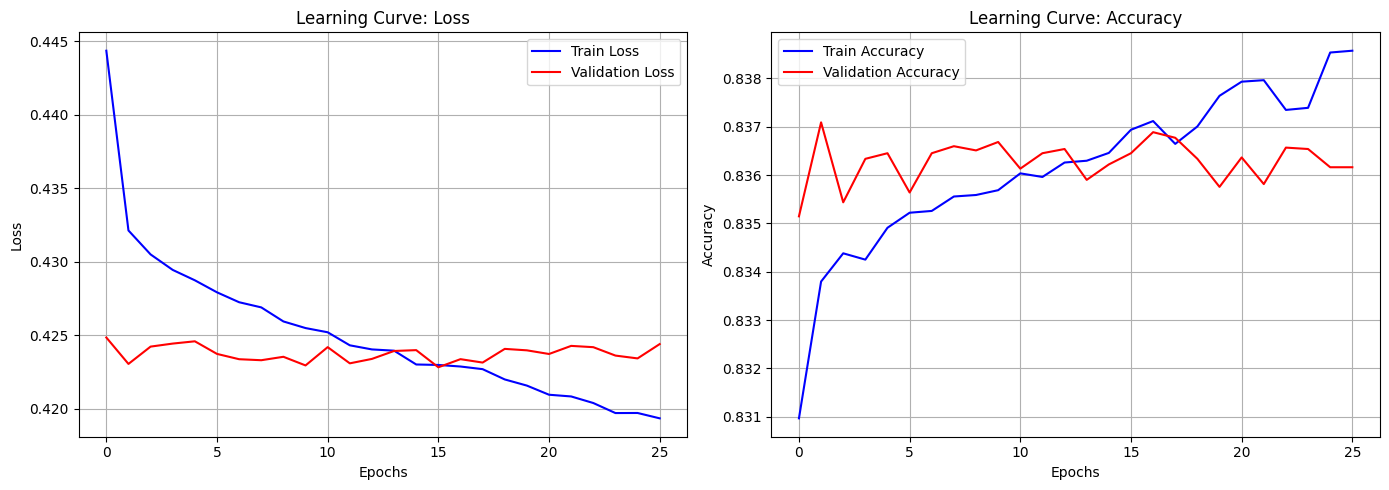


--- RENDIMIENTO FINAL EN TEST SET ---
Pérdida (Loss):     0.4232
Precisión (Accuracy): 0.8368

--- Visualizaciones de Optuna ---


In [ ]:
print("\nEntrenando el modelo final con los mejores hiperparámetros...")
best_model = create_model(study.best_trial)
best_batch_size = study.best_trial.params['batch_size']

final_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_final = best_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=best_batch_size,
    callbacks=[final_early_stopping],
    verbose=1
)


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Pérdida (Loss)
ax[0].plot(history_final.history['loss'], label='Train Loss', color='blue')
ax[0].plot(history_final.history['val_loss'], label='Validation Loss', color='red')
ax[0].set_title('Learning Curve: Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# Curva de Precisión (Accuracy)
ax[1].plot(history_final.history['accuracy'], label='Train Accuracy', color='blue')
ax[1].plot(history_final.history['val_accuracy'], label='Validation Accuracy', color='red')
ax[1].set_title('Learning Curve: Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluación final en Test Set
test_loss, test_acc = best_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n--- RENDIMIENTO FINAL EN TEST SET ---")
print(f"Pérdida (Loss):     {test_loss:.4f}")
print(f"Precisión (Accuracy): {test_acc:.4f}")

# Gráficas de Optuna
print("\n--- Visualizaciones de Optuna ---")
fig1 = plot_param_importances(study)
fig1.show()

fig2 = plot_parallel_coordinate(study)
fig2.show()


# Learning Curve Analysis:

Se puede observar en ambas gráficas de validation/training loss/accuracy vs epochs, que el modelo no está sufriendo de sobreajuste o subajuste, sino que se trata de un modelo con un ajuste apropiado.

Se concluye esto debido a que la pérdida y la exactitud de training y validación, aunque empiezan muy separadas, eventualmente comienzan a seguir el mismo patrón, con ninguna de las dos líneas de validación separándose demasiado de las líneas de entrenamiento.

Un modelo con sobreajuste mostraría una pérdida en validación mucho más alta que el entrenamiento, y un modelo con subajuste tendría puntuaciones bajas de exactitud en el entrenamiento y en la validación.

# Análisis de Visualizaciones de Optuna:

1. **Importancia de Hiperparámetros**: El factor más determinante para el éxito del modelo es el learning rate, seguido muy de lejos por el batch size (0.11) y el dropout (0.10). En nuestra tarea, eso demuestra que el modelo depende casi totalmente de su optimización matemática y no de su tamaño estructural, ya que el número de capas apenas impacta de 0.02.

2. **Gráfico de Coordenadas Paralelas**: Cada línea ilustra la "trayectoria" de un intento, conectando los hiperparámetros elegidos con su error final. Su propósito es revelar patrones de convergencia. Aunque la figura resalta un trial exploratorio de ejemplo (4 capas, learning rate ~0.006), el objetivo del gráfico es identificar las "zonas seguras": rangos específicos donde se agrupan visualmente los resultados de menor pérdida, confirmando así la lógica matemática de la arquitectura óptima de 2 capas.

# Model Evaluation and Testing Data

1078/1078 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


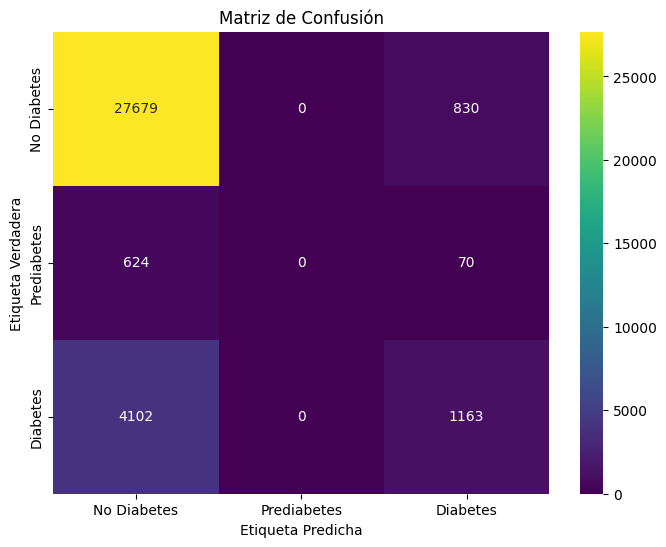

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Generar predicciones en el conjunto de prueba
y_pred_probs = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

#Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

#Desplegar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['No Diabetes','Prediabetes','Diabetes'],
            yticklabels=['No Diabetes','Prediabetes','Diabetes'])
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

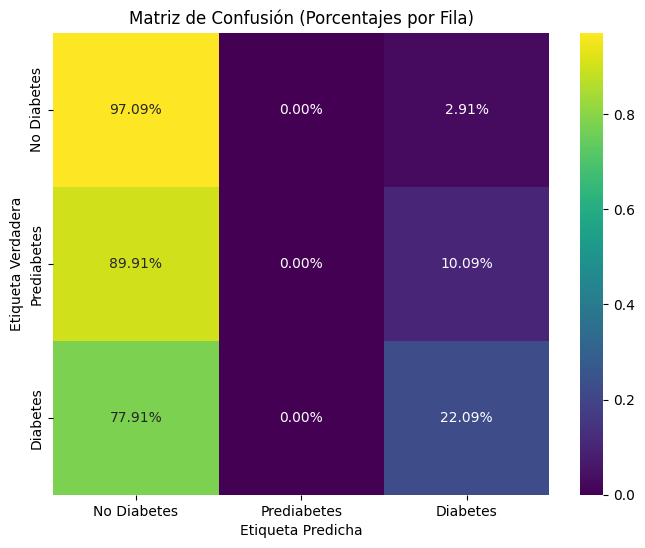

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt='.2%', cmap='viridis',
            xticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'])
plt.title('Matriz de Confusión (Porcentajes por Fila)')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

In [ ]:
# Calcular las métricas de rendimiento
print("\n--- Métricas de Rendimiento ---")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1-score (usando classification_report)
report = classification_report(y_test, y_pred, target_names=['No Diabetes', 'Prediabetes', 'Diabetes'], output_dict=True)

print("\nPrecision (macro avg): ", report['macro avg']['precision'])
print("Recall (macro avg): ", report['macro avg']['recall'])

# Specificity (calculado manualmente para cada clase)
def calculate_specificity(cm, class_id):
    # TN = sum of all elements - (TP + FN + FP)
    # TP = cm[class_id, class_id]
    # FN = sum(cm[class_id, :]) - TP
    # FP = sum(cm[:, class_id]) - TP

    TP = cm[class_id, class_id]
    FN = np.sum(cm[class_id, :]) - TP
    FP = np.sum(cm[:, class_id]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    if (TN + FP) == 0: # Avoid division by zero
        return 0.0
    return TN / (TN + FP)

print(f"Average Specificity: {np.mean(specificities):.4f}")
print("F1-score (macro avg): ", report['macro avg']['f1-score'])




--- Métricas de Rendimiento ---
Accuracy: 0.8368

Precision (macro avg):  0.4726334773415382
Recall (macro avg):  0.39725969143813805
Average Specificity: 0.7254
F1-score (macro avg):  0.4087340348688315


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Primero, el modelo tiene un accuracy decentemente alto, de 0.8368. Esto significa que 83.68% de las veces, el modelo predijo de manera correcta si una persona no tiene diabetes.

La precisión es una métrica más útil en este caso, ya que mide la proporción de predicciones positivas de cada clase que fueron correctas y las promedia. Con una precisión de 0.4726 significa que solamente 47.26% de las veces el modelo hizo una predicción correcta.

El recall indica la proporción de cantidades en donde el modelo identificó a un miembro de una de las tres clases de manera correcta. Con un valor de recall de 0.3973, significa que, en promedio, el modelo solamente pudo identificar a 39.73% de los casos de cada clase.

La especificidad mide qué tan bien el modelo puede identificar los casos que no son parte de una clase específica. Con una especificidad de 0.7254, significa que (en promedio entre las tres clases), el modelo identifica 72.54% de las veces cuando un caso NO es parte de una clase en realidad.

Finalmente, el F1-score es una medida que combina la precisión y el recall. Un F1-score de 0.4087 indica que el modelo no es capaz de obtener un balance entre evitar los falsos positivos (precisión) y la detección de verdaderos positivos (recall).

No creo que el modelo tenga un rendimiento aceptable como para ser útil. Aunque el accuracy parezca alto, las demás métricas son demasiado bajas.

# Save the Model

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import tensorflow as tf

model_filename = 'Diabetes012_model.keras'

best_model.save(model_filename)
print(f"Modelo guardado exitosamente como '{model_filename}'")

loaded_model = tf.keras.models.load_model(model_filename)
print(f"Modelo cargado exitosamente desde '{model_filename}'")

loaded_model.summary()

Modelo guardado exitosamente como 'Diabetes012_model.keras'
Modelo cargado exitosamente desde 'Diabetes012_model.keras'


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_125 (Dense)               │ (None, 464)            │        10,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 464)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (None, 304)            │       141,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_94 (Dropout)            │ (None, 304)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 16)             │         4,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,499 (1.79 MB)

 Trainable params: 156,499 (611.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 313,000 (1.19 MB)

Una vez guardado el modelo en un archivo .keras que guarda la arquitectura del modelo, los pesos, la configuración de entrenamiento y su estado, se puede apreciar que contiene los mismos resultados en las métricas con los mismos datos por lo que se podría confirmar que se guardó correctamente. Es de suma importancia y utilidad el guardar un modelo, ya que facilita el proceso de usar el modelo para nuevas predicciones sin tener que reentrenarlo.

# Conclusión Personal


1. **Diego Marcelo González Luján**: Esta actividad me permitió comprender que el entrenamiento de redes neuronales depende más de la optimización matemática que del tamaño estructural, pues la importancia del **learning rate** (0.53) superó drásticamente al número de capas (0.02). El mayor desafío fue el desbalance de clases del dataset lo que resultó en un F1-score bajo (0.4087) a pesar de tener un accuracy aceptable, demostrando que el modelo tiene dificultades para identificar casos reales de diabetes. La implementación de Optuna fue altamente efectiva para encontrar la configuración ganadora del Trial 8 de forma eficiente, mientras que el Early Stopping garantizó un modelo final libre de sobreajuste al restaurar automáticamente los mejores pesos durante el entrenamiento.

GitHub: https://github.com/DiegoLujan198/06-multilayer-neural-network-with-hyperparameter-optimisation-Equipo-3.ipynb.git

2. **Mauricio Alejandro González Campos**: Al hacer mi porción de esta actividad, aprendí sobre la importancia de balancear la base de datos a usar antes de insertarla al modelo, ya que creo que fue, al menos parcialmente, debido al desbalance de clases que el modelo no alcanzó un rendimiento aceptable para el uso real. Además, tuve la oportunidad de repasar los significados de cada una de las métricas de la matriz de confusión (Accuracy, Precision, etc.), y aprendí que aunque unas métricas podrían parecer bien "en papel", no significa que el modelo tenga un buen rendimiento.

GitHub: https://github.com/MauriGzz555/06-multilayer-neural-network

3. **Jesús Esteban Bustamante Apodaca**: Esta actividad fue de gran ayuda para mi aprendizaje en los temas de redes neuronales multicapas, aprendí más sobre la optimización de hiperparámetros usando la optimización Bayesiana para el entrenamiento del modelo, y el uso de la herramienta del Early Stopping para reducir el número de épocas entrenadas si el modelo no mejora. Los resultados de esta actividad me dejó ver la importancia de balancear la base de datos, pues el modelo no tuvo un rendimiento aceptable por los pocos registros de las clases de "prediabetes" y "diabetes" por lo que en la predicción de esas variables con pocas referencias en su entrenamiento abarcaba más las predicciones la clase "no diabetes", resultando en un modelo ineficiente.

Github: https://github.com/EstebanBA-UDEM/06-multilayer-neural-network

# Referencias

Teboul, A. (2021). Diabetes Health Indicators Dataset. Kaggle. https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset